## (*) **Rohit Goutam Maity**, CSC 583 and assignment number #2, Student Id: 2188913

## Colaborated with GenAI
<br>  
<br>


# CSC 583 HW#2: Exploring Word Vectors (Total 5 points)

This code is adopted almost verbatim from Assign #1 from Stanford University, CS224n Natural Language Processing with Deep Learning course (https://web.stanford.edu/class/cs224n/).

===========================================================

Before you start, make sure you **read the README.md** in the same directory as this notebook for important setup information. You need to install some Python libraries before you can successfully do this assignment. A lot of code is provided in this notebook, and we highly encourage you to read and understand it as part of the learning :)

If you aren't super familiar with Python, Numpy, or Matplotlib, the CS231N Python/Numpy [tutorial](https://cs231n.github.io/python-numpy-tutorial/) is a great resource.

**Assignment Notes:** Be sure to read the <font color='blue'>submission instructions</font> located at the bottom of the notebook.


In [ ]:
!pip install gensim
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 13.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatib

In [ ]:
# All Import Statements Defined Here
# Note: Do not add to this list.
# ----------------

import sys
assert sys.version_info[0] == 3
assert sys.version_info[1] >= 8

from platform import python_version
assert int(python_version().split(".")[1]) >= 5, "Please upgrade your Python version following the instructions in \
    the README.md file found in the same directory as this notebook. Your Python version is " + python_version()

from gensim.models import KeyedVectors
from gensim.test.utils import datapath
import pprint
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 5]

from datasets import load_dataset
imdb_dataset = load_dataset("stanfordnlp/imdb", name="plain_text")

import re
import numpy as np
import random
import scipy as sp
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA

START_TOKEN = '<START>'
END_TOKEN = '<END>'
NUM_SAMPLES = 150

np.random.seed(0)
random.seed(0)
# ----------------

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

## Word Vectors

Word Vectors are often used as a fundamental component for downstream NLP tasks, e.g. question answering, text generation, translation, etc., so it is important to build some intuitions as to their strengths and weaknesses. Here, you will explore two types of word vectors: those derived from *co-occurrence matrices*, and those derived via *GloVe*.

**Note on Terminology:** The terms "word vectors" and "word embeddings" are often used interchangeably. The term "embedding" refers to the fact that we are encoding aspects of a word's meaning in a lower dimensional space. As [Wikipedia](https://en.wikipedia.org/wiki/Word_embedding) states, "*conceptually it involves a mathematical embedding from a space with one dimension per word to a continuous vector space with a much lower dimension*".

## Part 1: Count-Based Word Vectors (Total 2 points)

Most word vector models start from the following idea:

*You shall know a word by the company it keeps ([Firth, J. R. 1957:11](https://en.wikipedia.org/wiki/John_Rupert_Firth))*

Many word vector implementations are driven by the idea that similar words, i.e., (near) synonyms, will be used in similar contexts. As a result, similar words will often be spoken or written along with a shared subset of words, i.e., contexts. By examining these contexts, we can try to develop embeddings for our words. With this intuition in mind, many "old school" approaches to constructing word vectors relied on word counts. Here we elaborate upon one of those strategies, *co-occurrence matrices* (for more information, see [here](https://web.stanford.edu/~jurafsky/slp3/6.pdf) or [here](https://web.archive.org/web/20190530091127/https://medium.com/data-science-group-iitr/word-embedding-2d05d270b285)).

### Co-Occurrence

A co-occurrence matrix counts how often things co-occur in some environment. Given some word $w_i$ occurring in the document, we consider the *context window* surrounding $w_i$. Supposing our fixed window size is $n$, then this is the <b>$n$ preceding and $n$ subsequent words</b> in that document, i.e. words $w_{i-n} \dots w_{i-1}$ and $w_{i+1} \dots w_{i+n}$. We build a *co-occurrence matrix* $M$, which is a symmetric word-by-word matrix in which $M_{ij}$ is the number of times $w_j$ appears inside $w_i$'s window among all documents.

**Example: Co-Occurrence with Fixed Window of n=1**:

Document 1: "all that glitters is not gold"

Document 2: "all is well that ends well"


|     *    | `<START>` | all | that | glitters | is   | not  | gold  | well | ends | `<END>` |
|----------|-------|-----|------|----------|------|------|-------|------|------|-----|
| `<START>`    | 0     | 2   | 0    | 0        | 0    | 0    | 0     | 0    | 0    | 0   |
| all      | 2     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| that     | 0     | 1   | 0    | 1        | 0    | 0    | 0     | 1    | 1    | 0   |
| glitters | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 0    | 0   |
| is       | 0     | 1   | 0    | 1        | 0    | 1    | 0     | 1    | 0    | 0   |
| not      | 0     | 0   | 0    | 0        | 1    | 0    | 1     | 0    | 0    | 0   |
| gold     | 0     | 0   | 0    | 0        | 0    | 1    | 0     | 0    | 0    | 1   |
| well     | 0     | 0   | 1    | 0        | 1    | 0    | 0     | 0    | 1    | 1   |
| ends     | 0     | 0   | 1    | 0        | 0    | 0    | 0     | 1    | 0    | 0   |
| `<END>`      | 0     | 0   | 0    | 0        | 0    | 0    | 1     | 1    | 0    | 0   |

In NLP, we commonly use `<START>` and `<END>` tokens to mark the beginning and end of sentences, paragraphs, or documents. These tokens are included in co-occurrence counts, encapsulating each document, for example: "`<START>` All that glitters is not gold `<END>`".

The matrix rows (or columns) provide word vectors based on word-word co-occurrence, but they can be large. To reduce dimensionality, we employ <b>Singular Value Decomposition (SVD)</b>, akin to PCA, selecting the top $k$ principal components. The SVD process decomposes the co-occurrence matrix $A$ into singular values in the diagonal $S$ matrix and new, shorter word vectors in $U_k$.

This dimensionality reduction maintains semantic relationships; for instance, *doctor* and *hospital* will be closer than *doctor* and *dog*.

### Plotting Co-Occurrence Word Embeddings

Here, we will be using the Large Movie Review Dataset. This is a dataset for binary sentiment classification containing substantially more data than previous benchmark datasets. We provide a set of 25,000 highly polar movie reviews for training, and 25,000 for testing. There is additional unlabeled data for use as well. We provide a `read_corpus` function below that pulls out the text of a movie review from the dataset. The function also adds `<START>` and `<END>` tokens to each of the documents, and lowercases words. You do **not** have to perform any other kind of pre-processing.

In [ ]:
def read_corpus():
    """ Read files from the Large Movie Review Dataset.
        Params:
            category (string): category name
        Return:
            list of lists, with words from each of the processed files
    """
    files = imdb_dataset["train"]["text"][:NUM_SAMPLES]
    return [[START_TOKEN] + [re.sub(r'[^\w]', '', w.lower()) for w in f.split(" ")] + [END_TOKEN] for f in files]

Let's have a look what these documents are like….

In [ ]:
imdb_corpus = read_corpus()
pprint.pprint(imdb_corpus[:3], compact=True, width=100)
print("corpus size: ", len(imdb_corpus[0]))

[['<START>', 'i', 'rented', 'i', 'am', 'curiousyellow', 'from', 'my', 'video', 'store', 'because',
  'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first',
  'released', 'in', '1967', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized',
  'by', 'us', 'customs', 'if', 'it', 'ever', 'tried', 'to', 'enter', 'this', 'country', 'therefore',
  'being', 'a', 'fan', 'of', 'films', 'considered', 'controversial', 'i', 'really', 'had', 'to',
  'see', 'this', 'for', 'myselfbr', 'br', 'the', 'plot', 'is', 'centered', 'around', 'a', 'young',
  'swedish', 'drama', 'student', 'named', 'lena', 'who', 'wants', 'to', 'learn', 'everything',
  'she', 'can', 'about', 'life', 'in', 'particular', 'she', 'wants', 'to', 'focus', 'her',
  'attentions', 'to', 'making', 'some', 'sort', 'of', 'documentary', 'on', 'what', 'the', 'average',
  'swede', 'thought', 'about', 'certain', 'political', 'issues', 'such', 'as', 'the', 'vietnam',
  'war', 'and', 'race', 'issu

### Question 1.1: Implement `distinct_words` [code] (0.4 points)

Write a method to work out the distinct words (word types) that occur in the corpus.

You can use `for` loops to process the input `corpus` (a list of list of strings), but try using Python list comprehensions (which are generally faster). In particular, [this](https://coderwall.com/p/rcmaea/flatten-a-list-of-lists-in-one-line-in-python) may be useful to flatten a list of lists. If you're not familiar with Python list comprehensions in general, here's [more information](https://python-3-patterns-idioms-test.readthedocs.io/en/latest/Comprehensions.html).

Your returned `corpus_words` should be sorted. You can use python's `sorted` function for this.

You may find it useful to use [Python sets](https://www.w3schools.com/python/python_sets.asp) to remove duplicate words.

In [ ]:
def distinct_words(corpus):
    """ Determine a list of distinct words for the corpus.
        Params:
            corpus (list of list of strings): corpus of documents
        Return:
            corpus_words (list of strings): sorted list of distinct words across the corpus
            n_corpus_words (integer): number of distinct words across the corpus
    """
    corpus_words = []
    n_corpus_words = -1

    # ------------------
    # Write your implementation here.
    # Flatten the corpus and get unique words using set
    # Use list comprehension to flatten: [word for document in corpus for word in document]
    all_words = [word for document in corpus for word in document]

    # get unique words using set and sort them
    corpus_words = sorted(set(all_words))

    # Get the count
    n_corpus_words = len(corpus_words)
    # ------------------

    return corpus_words, n_corpus_words

In [ ]:
# ---------------------
# Run this sanity check
# Note that this not an exhaustive check for correctness.
# ---------------------

# Define toy corpus
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
test_corpus_words, num_corpus_words = distinct_words(test_corpus)

# Correct answers
ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN])
ans_num_corpus_words = len(ans_test_corpus_words)

# Test correct number of words
assert(num_corpus_words == ans_num_corpus_words), "Incorrect number of distinct words. Correct: {}. Yours: {}".format(ans_num_corpus_words, num_corpus_words)

# Test correct words
assert (test_corpus_words == ans_test_corpus_words), "Incorrect corpus_words.\nCorrect: {}\nYours:   {}".format(str(ans_test_corpus_words), str(test_corpus_words))

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### Question 1.2: Implement `compute_co_occurrence_matrix` [code] (0.6 points)

Write a method that constructs a co-occurrence matrix for a certain window-size $n$ (with a default of 4), considering words $n$ before and $n$ after the word in the center of the window. Here, we start to use `numpy (np)` to represent vectors, matrices, and tensors.


In [ ]:
def compute_co_occurrence_matrix(corpus, window_size=4):
    """ Compute co-occurrence matrix for the given corpus and window_size (default of 4).

        Note: Each word in a document should be at the center of a window. Words near edges will have a smaller
              number of co-occurring words.

              For example, if we take the document "<START> All that glitters is not gold <END>" with window size of 4,
              "All" will co-occur with "<START>", "that", "glitters", "is", and "not".

        Params:
            corpus (list of list of strings): corpus of documents
            window_size (int): size of context window
        Return:
            M (a symmetric numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)):
                Co-occurence matrix of word counts.
                The ordering of the words in the rows/columns should be the same as the ordering of the words given by the distinct_words function.
            word2ind (dict): dictionary that maps word to index (i.e. row/column number) for matrix M.
    """
    words, n_words = distinct_words(corpus)
    M = None
    word2ind = {}

    # ------------------
    # Write your implementation here.
    # Create word2ind dictionary mapping words to indices
    word2ind = {word: i for i, word in enumerate(words)}

    # Initialize the co-occurrence matrix with zeros
    M = np.zeros((n_words, n_words))

    # Iterate through document in the corpus
    for document in corpus:
        # Iterate through each word in corpus
        for center_pos, center_word in enumerate(document):
            # Get the center word index
            center_idx = word2ind[center_word]

            # Define the context window boundaries
            start_pos = max(0, center_pos - window_size)
            end_pos = min(len(document), center_pos + window_size + 1)

            # Iterate through context words in the window
            for context_pos in range(start_pos, end_pos):
                # Skip the center word itself
                if context_pos == center_pos:
                    continue

                context_word = document[context_pos]
                context_idx = word2ind[context_word]

                # Increment the co-occurrence count (symmetric)
                M[center_idx, context_idx] += 1

    # ------------------

    return M, word2ind

In [ ]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# ---------------------

# Define toy corpus and get student's co-occurrence matrix
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)

# Correct M and word2ind
M_test_ans = np.array(
    [[0., 0., 0., 0., 0., 0., 1., 0., 0., 1.,],
     [0., 0., 1., 1., 0., 0., 0., 0., 0., 0.,],
     [0., 1., 0., 0., 0., 0., 0., 0., 1., 0.,],
     [0., 1., 0., 0., 0., 0., 0., 0., 0., 1.,],
     [0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,],
     [0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,],
     [1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,],
     [0., 0., 0., 0., 0., 1., 1., 0., 0., 0.,],
     [0., 0., 1., 0., 1., 1., 0., 0., 0., 1.,],
     [1., 0., 0., 1., 1., 0., 0., 0., 1., 0.,]]
)
ans_test_corpus_words = sorted([START_TOKEN, "All", "ends", "that", "gold", "All's", "glitters", "isn't", "well", END_TOKEN])
word2ind_ans = dict(zip(ans_test_corpus_words, range(len(ans_test_corpus_words))))

# Test correct word2ind
assert (word2ind_ans == word2ind_test), "Your word2ind is incorrect:\nCorrect: {}\nYours: {}".format(word2ind_ans, word2ind_test)

# Test correct M shape
assert (M_test.shape == M_test_ans.shape), "M matrix has incorrect shape.\nCorrect: {}\nYours: {}".format(M_test.shape, M_test_ans.shape)

# Test correct M values
for w1 in word2ind_ans.keys():
    idx1 = word2ind_ans[w1]
    for w2 in word2ind_ans.keys():
        idx2 = word2ind_ans[w2]
        student = M_test[idx1, idx2]
        correct = M_test_ans[idx1, idx2]
        if student != correct:
            print("Correct M:")
            print(M_test_ans)
            print("Your M: ")
            print(M_test)
            raise AssertionError("Incorrect count at index ({}, {})=({}, {}) in matrix M. Yours has {} but should have {}.".format(idx1, idx2, w1, w2, student, correct))

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### Question 1.3: Implement `reduce_to_k_dim` [code] (0.4 point)

Construct a method that performs dimensionality reduction on the matrix to produce k-dimensional embeddings. Use SVD to take the top k components and produce a new matrix of k-dimensional embeddings.

**Note:** All of numpy, scipy, and scikit-learn (`sklearn`) provide *some* implementation of SVD, but only scipy and sklearn provide an implementation of Truncated SVD, and only sklearn provides an efficient randomized algorithm for calculating large-scale Truncated SVD. So please use [sklearn.decomposition.TruncatedSVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).

In [ ]:
def reduce_to_k_dim(M, k=2):
    """ Reduce a co-occurence count matrix of dimensionality (num_corpus_words, num_corpus_words)
        to a matrix of dimensionality (num_corpus_words, k) using the following SVD function from Scikit-Learn:
            - http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html

        Params:
            M (numpy matrix of shape (number of unique words in the corpus , number of unique words in the corpus)): co-occurence matrix of word counts
            k (int): embedding size of each word after dimension reduction
        Return:
            M_reduced (numpy matrix of shape (number of corpus words, k)): matrix of k-dimensioal word embeddings.
                    In terms of the SVD from math class, this actually returns U * S
    """
    n_iters = 10    # Use this parameter in your call to `TruncatedSVD`
    M_reduced = None
    print("Running Truncated SVD over %i words..." % (M.shape[0]))

    # ------------------
    # Write your implementation here.
    # create TruncatedSVD instance
    svd = TruncatedSVD(n_components=k, n_iter=n_iters, random_state=0)

    # Fit and transform the matrix M
    M_reduced = svd.fit_transform(M)

    # ------------------

    print("Done.")
    return M_reduced

In [ ]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness
# In fact we only check that your M_reduced has the right dimensions.
# ---------------------

# Define toy corpus and run student code
test_corpus = ["{} All that glitters isn't gold {}".format(START_TOKEN, END_TOKEN).split(" "), "{} All's well that ends well {}".format(START_TOKEN, END_TOKEN).split(" ")]
M_test, word2ind_test = compute_co_occurrence_matrix(test_corpus, window_size=1)
M_test_reduced = reduce_to_k_dim(M_test, k=2)

# Test proper dimensions
assert (M_test_reduced.shape[0] == 10), "M_reduced has {} rows; should have {}".format(M_test_reduced.shape[0], 10)
assert (M_test_reduced.shape[1] == 2), "M_reduced has {} columns; should have {}".format(M_test_reduced.shape[1], 2)

# Print Success
print ("-" * 80)
print("Passed All Tests!")
print ("-" * 80)

Running Truncated SVD over 10 words...
Done.
--------------------------------------------------------------------------------
Passed All Tests!
--------------------------------------------------------------------------------


### Question 1.4: Implement `plot_embeddings` [code] (0.4 point)

Here you will write a function to plot a set of 2D vectors in 2D space. For graphs, we will use Matplotlib (`plt`).

For this example, you may find it useful to adapt [this code](http://web.archive.org/web/20190924160434/https://www.pythonmembers.club/2018/05/08/matplotlib-scatter-plot-annotate-set-text-at-label-each-point/). In the future, a good way to make a plot is to look at [the Matplotlib gallery](https://matplotlib.org/gallery/index.html), find a plot that looks somewhat like what you want, and adapt the code they give.

In [ ]:
def plot_embeddings(M_reduced, word2ind, words):
    """ Plot in a scatterplot the embeddings of the words specified in the list "words".
        NOTE: do not plot all the words listed in M_reduced / word2ind.
        Include a label next to each point.

        Params:
            M_reduced (numpy matrix of shape (number of unique words in the corpus , 2)): matrix of 2-dimensioal word embeddings
            word2ind (dict): dictionary that maps word to indices for matrix M
            words (list of strings): words whose embeddings we want to visualize
    """

    # ------------------
    # Write your implementation here.
    # Extract x and y coordinates for the specified words
    x_coords = []
    y_coords = []
    labels = []

    for word in words:
        if word in word2ind:
            idx = word2ind[word]
            x_coords.append(M_reduced[idx, 0])
            y_coords.append(M_reduced[idx, 1])
            labels.append(word)

    # create scatter plot
    plt.figure(figsize=(10, 8))
    plt.scatter(x_coords, y_coords, marker='o', s = 100)

    # Add labels to the points
    for i, label in enumerate(labels):
        plt.annotate(label, (x_coords[i], y_coords[i]),
                     xytext=(5, 5), textcoords='offset points',
                     fontsize=12)

    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.title('2D Word Embeddings')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Add labels to the points

    # ------------------

--------------------------------------------------------------------------------
Outputted Plot:


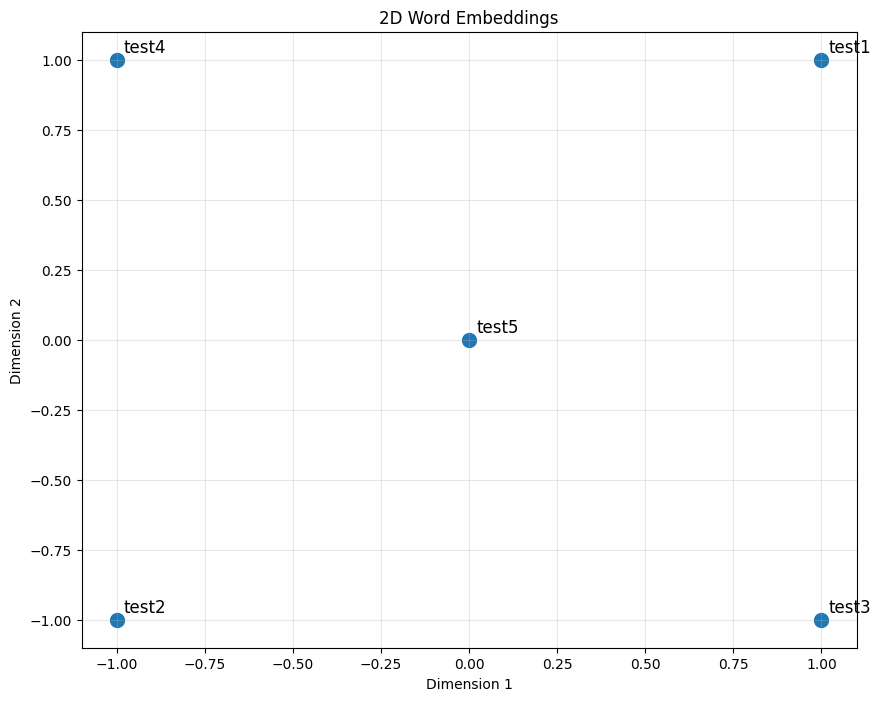

--------------------------------------------------------------------------------


In [ ]:
# ---------------------
# Run this sanity check
# Note that this is not an exhaustive check for correctness.
# The plot produced should look like the included file question_1.4_test.png
# ---------------------

print ("-" * 80)
print ("Outputted Plot:")

M_reduced_plot_test = np.array([[1, 1], [-1, -1], [1, -1], [-1, 1], [0, 0]])
word2ind_plot_test = {'test1': 0, 'test2': 1, 'test3': 2, 'test4': 3, 'test5': 4}
words = ['test1', 'test2', 'test3', 'test4', 'test5']
plot_embeddings(M_reduced_plot_test, word2ind_plot_test, words)

print ("-" * 80)

### Question 1.5: Co-Occurrence Plot Analysis [written] (0.5 points)

Now we will put together all the parts you have written! We will compute the co-occurrence matrix with fixed window of 4 (the default window size), over the Large Movie Review corpus. Then we will use TruncatedSVD to compute 2-dimensional embeddings of each word. TruncatedSVD returns U\*S, so we need to normalize the returned vectors, so that all the vectors will appear around the unit circle (therefore closeness is directional closeness). **Note**: The line of code below that does the normalizing uses the NumPy concept of *broadcasting*. If you don't know about broadcasting, check out
[Computation on Arrays: Broadcasting by Jake VanderPlas](https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html).

Run the below cell to produce the plot. It can take up to a few minutes to run.

Running Truncated SVD over 5880 words...
Done.


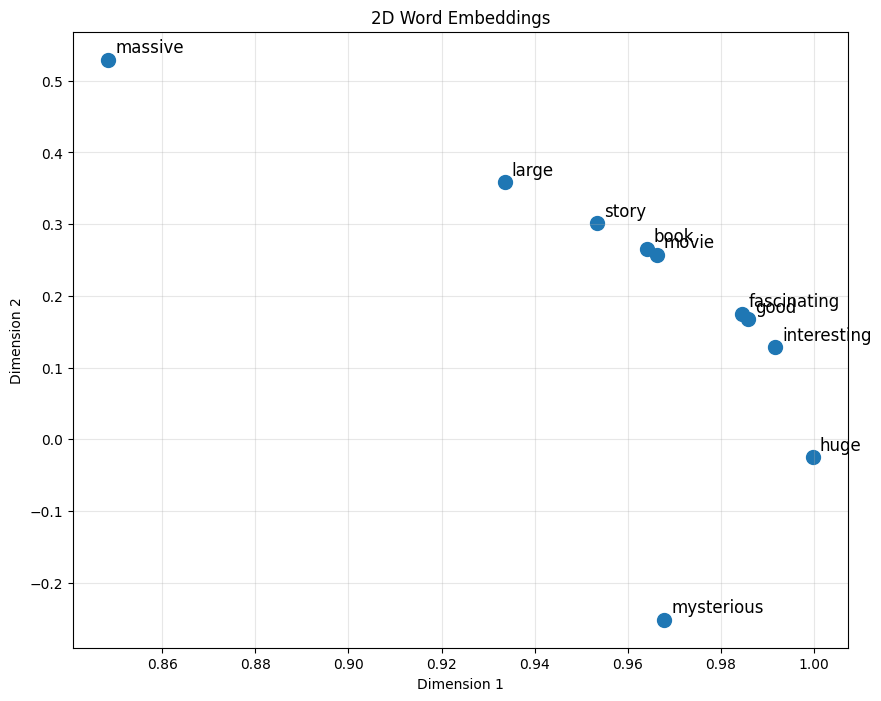

In [ ]:
# -----------------------------
# Run This Cell to Produce Your Plot
# ------------------------------
imdb_corpus = read_corpus()
M_co_occurrence, word2ind_co_occurrence = compute_co_occurrence_matrix(imdb_corpus)
M_reduced_co_occurrence = reduce_to_k_dim(M_co_occurrence, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced_co_occurrence, axis=1)
M_normalized = M_reduced_co_occurrence / M_lengths[:, np.newaxis] # broadcasting

words = ['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']

plot_embeddings(M_normalized, word2ind_co_occurrence, words)

**Verify that your figure matches "question_1.5.png" in the assignment zip. If not, use the figure in "question_1.5.png" to answer the next two questions.**

a. Find at least two groups of words that cluster together in 2-dimensional embedding space. Give an explanation for each cluster you observe.

#### <font color="red">Write your answer here.</font>

**Cluster 1: Content/Media words (story, book, movie)**
These three words form a tight cluster in the center-right region (around x=0.96-0.97, y=0.26-0.30). They cluster together because they represent different forms of narrative media and frequently co-occur in movie review contexts. Reviewers often discuss how "the movie is based on a book," compare "the story in the book versus the movie," or evaluate "the movie's story," causing these words to share similar co-occurrence patterns.

**Cluster 2: Positive evaluative adjectives (good, fascinating, interesting)**
These words cluster together in the right region (around x=0.98-0.99, y=0.13-0.19). They are all positive descriptive words used to express approval or engagement with content. In movie reviews, these adjectives appear in similar contexts when critics describe compelling aspects of films, leading to overlapping co-occurrence patterns with words like "plot," "characters," "performance," etc.

**Cluster 3: Size descriptors (large, huge) with some separation**
While "large" (x≈0.93, y≈0.36) and "huge" (x≈1.00, y≈-0.03) are both size-related words, they show moderate clustering tendency. They likely appear in similar contexts describing scale ("large budget," "huge cast"), though "huge" appears slightly separated, suggesting some contextual differences in usage.


b. What doesn't cluster together that you might think should have? Describe at least two examples.

#### <font color="red">Write your answer here.</font>

**Example 1: "massive" is far from "large" and "huge"**

Despite being synonyms that all describe size or magnitude, "massive" (x≈0.85, y≈0.54) is positioned quite far from "large" (x≈0.93, y≈0.36) and "huge" (x≈1.00, y≈-0.03). You would expect these three size-related words to form a tight cluster. The separation suggests that in movie reviews, "massive" is used in different contexts—perhaps more frequently in abstract or figurative expressions like "massive disappointment," "massive hit," or "massive failure"—while "large" and "huge" may appear more in concrete descriptions of physical attributes like cast size, budget, or scale.

**Example 2: "mysterious" doesn't cluster with descriptive adjectives**

"Mysterious" (x≈0.97, y≈-0.25) is isolated at the bottom of the plot, separated from other descriptive adjectives like "good," "fascinating," and "interesting" (y≈0.13-0.19). Since all four are adjectives that describe qualities of movies or stories, you might expect them to appear close together. However, "mysterious" seems to be used in more specialized contexts, likely associated with specific genres (mystery, thriller), plot characteristics, or atmospheric descriptions rather than general evaluative commentary. This specialized usage pattern creates different co-occurrence patterns, explaining why it doesn't cluster with the more general-purpose descriptive words.

## Part 2: Prediction-Based Word Vectors (3 points)

We explore the embeddings produced by GloVe. Although GloVe is not purely 'prediction-based' like word2vec, its training objective is predictive. If you're feeling adventurous, challenge yourself and try reading [GloVe's original paper](https://nlp.stanford.edu/pubs/glove.pdf).

Run the following cells to load the GloVe vectors into memory. **Note**: If this is your first time to run these cells, i.e. download the embedding model, it will take a couple minutes to run. If you've run these cells before, rerunning them will load the model without redownloading it, which will take about 1 to 2 minutes.

In [ ]:
def load_embedding_model():
    """ Load GloVe Vectors
        Return:
            wv_from_bin: All 400000 embeddings, each length 200
    """
    import gensim.downloader as api
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin

# Load the GloVe embeddings
wv_from_bin = load_embedding_model()

[==================================================] 100.0% 252.1/252.1MB downloaded
Loaded vocab size 400000


#### Note: If you are receiving a "reset by peer" error, rerun the cell to restart the download.

### Reducing dimensionality of Word Embeddings
Let's directly compare the GloVe embeddings to those of the co-occurrence matrix. In order to avoid running out of memory, we will work with a sample of 40000 GloVe vectors instead.
Run the following cells to:

1. Put 40000 Glove vectors into a matrix M
2. Run `reduce_to_k_dim` (your Truncated SVD function) to reduce the vectors from 200-dimensional to 2-dimensional.

In [ ]:
def get_matrix_of_vectors(wv_from_bin, required_words):
    """ Put the GloVe vectors into a matrix M.
        Param:
            wv_from_bin: KeyedVectors object; the 400000 GloVe vectors loaded from file
        Return:
            M: numpy matrix shape (num words, 200) containing the vectors
            word2ind: dictionary mapping each word to its row number in M
    """
    import random
    words = list(wv_from_bin.index_to_key)
    print("Shuffling words ...")
    random.seed(225)
    random.shuffle(words)
    print("Putting %i words into word2ind and matrix M..." % len(words))
    word2ind = {}
    M = []
    curInd = 0
    for w in words:
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    for w in required_words:
        if w in words:
            continue
        try:
            M.append(wv_from_bin.get_vector(w))
            word2ind[w] = curInd
            curInd += 1
        except KeyError:
            continue
    M = np.stack(M)
    print("Done.")
    return M, word2ind

In [ ]:
# -----------------------------------------------------------------
# Run Cell to Reduce 200-Dimensional Word Embeddings to k Dimensions
# Note: This should be quick to run
# -----------------------------------------------------------------
M, word2ind = get_matrix_of_vectors(wv_from_bin, words)
M_reduced = reduce_to_k_dim(M, k=2)

# Rescale (normalize) the rows to make them each of unit-length
M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis] # broadcasting

Shuffling words ...
Putting 400000 words into word2ind and matrix M...
Done.
Running Truncated SVD over 400000 words...
Done.


**Note: If you are receiving out of memory issues on your local machine, try closing other applications to free more memory on your device. You may want to try restarting your machine so that you can free up extra memory. Then immediately run the jupyter notebook and see if you can load the word vectors properly. If you still have problems with loading the embeddings onto your local machine after this, please go to office hours or contact course staff.**

### Question 2.1: GloVe Plot Analysis [written] (0.4 points)

Run the cell below to plot the 2D GloVe embeddings for `['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']`.

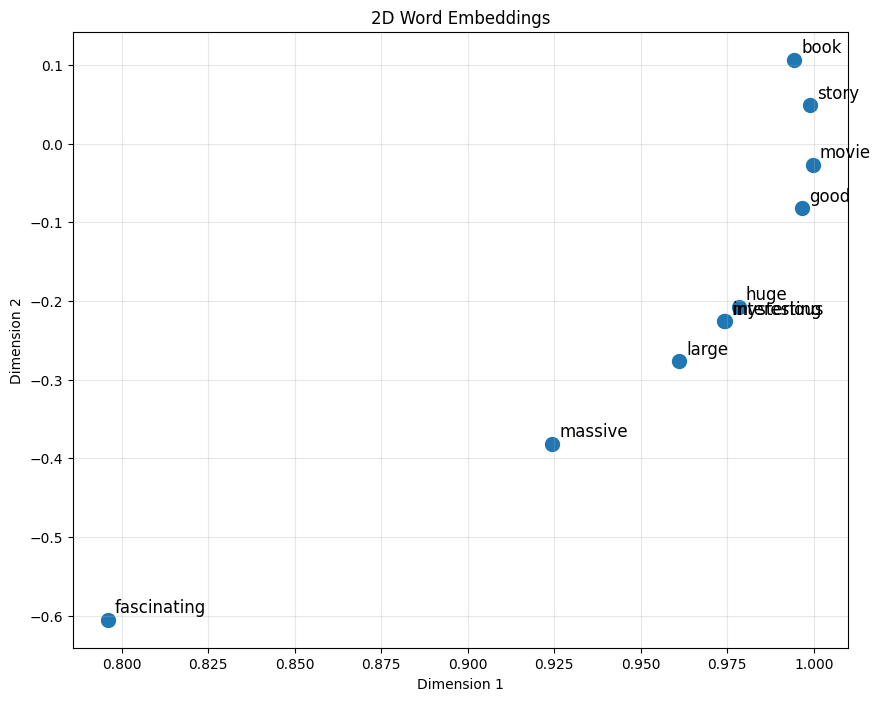

In [ ]:
words = ['movie', 'book', 'mysterious', 'story', 'fascinating', 'good', 'interesting', 'large', 'massive', 'huge']

plot_embeddings(M_reduced_normalized, word2ind, words)

**Verify that your figure matches "question_2.1.png" in the assignment zip. If not, use the figure in "question_2.1.png" (and the figure in "question_1.5.png", if applicable) to answer the next two questions.**

a. What is one way the plot is different from the one generated earlier from the co-occurrence matrix? What is one way it's similar?

#### <font color="red">Write your answer here.</font>

**Difference:**
The GloVe plot shows much tighter, more coherent clustering compared to the co-occurrence matrix plot. The size-related words (large, huge, massive) now cluster much closer together in a defined region, whereas in the co-occurrence plot "massive" was quite separated. The overall structure is more compact and organized, with clearer semantic groupings. Additionally, the relative positions have changed significantly, for instance, "fascinating" is now isolated in the bottom-left corner rather than clustering with other positive adjectives.

**Similarity:**
Both plots preserve the general semantic relationship between content/media words (book, story, movie), which cluster together in both visualizations. In both cases, these three words form a recognizable group, indicating that this core semantic relationship is captured by both embedding methods despite their different approaches.

b. Why might the GloVe plot (question_2.1.png) differ from the plot generated earlier from the co-occurrence matrix (question_1.5.png)?

#### <font color="red">Write your answer here.</font>

The GloVe plot differs from the co-occurrence matrix plot for several fundamental reasons:

1. Corpus size and diversity: GloVe embeddings were trained on a massive, diverse corpus (Wikipedia + Gigaword with billions of words across many topics), while our co-occurrence matrix was built from only 150 IMDB movie reviews. The larger corpus provides exponentially more statistical evidence about how words relate across varied contexts, leading to more robust and generalizable embeddings.

2. Training methodology: GloVe uses a sophisticated weighted least-squares regression model that optimizes word vectors to capture the ratio of co-occurrence probabilities. This mathematical framework is designed to encode semantic relationships effectively. In contrast, our co-occurrence matrix simply counts raw co-occurrences within fixed windows, then applies SVD for dimensionality reduction without any semantic optimization.

3. Global vs. local statistics: GloVe explicitly models global corpus statistics by considering the entire co-occurrence matrix during training, while our method only captures local context windows. This global perspective helps GloVe better capture broader semantic patterns and word relationships.

4. Domain specialization: Our co-occurrence embeddings reflect the specific language patterns of movie reviews (heavy use of evaluative language, genre terms, etc.), while GloVe reflects general English usage from encyclopedic and news sources. This explains why certain word relationships might be stronger or weaker in each embedding space.

5. Dimensionality reduction approach: GloVe learns 200-dimensional vectors directly through its optimization objective, which we then reduce to 2D. Our method creates a potentially very high-dimensional co-occurrence matrix first, then reduces it. Information loss during reduction affects these differently.

### Cosine Similarity
Now that we have word vectors, we need a way to quantify the similarity between individual words, according to these vectors. One such metric is cosine-similarity. We will be using this to find words that are "close" and "far" from one another.

We can think of n-dimensional vectors as points in n-dimensional space. If we take this perspective [L1](http://mathworld.wolfram.com/L1-Norm.html) and [L2](http://mathworld.wolfram.com/L2-Norm.html) Distances help quantify the amount of space "we must travel" to get between these two points. Another approach is to examine the angle between two vectors. From trigonometry we know that:

<img src="./imgs/inner_product.png" width=20% style="float: center;"></img>

Instead of computing the actual angle, we can leave the similarity in terms of $similarity = cos(\Theta)$. Formally the [Cosine Similarity](https://en.wikipedia.org/wiki/Cosine_similarity) $s$ between two vectors $p$ and $q$ is defined as:

$$s = \frac{p \cdot q}{||p|| ||q||}, \textrm{ where } s \in [-1, 1] $$

### Question 2.2: Words with Multiple Meanings (0.4 points) [code + written]
Polysemes and homonyms are words that have more than one meaning (see this [wiki page](https://en.wikipedia.org/wiki/Polysemy) to learn more about the difference between polysemes and homonyms ). Find a word with *at least two VERY different meanings* such that the top-10 most similar words (according to cosine similarity) contain related words from *both* meanings. For example, a noun <b>"bat"</b> has both "a flying mammal" and "a sports equipment" meanings in the top 10, and a verb <b>"strike"</b> has both "to hit" and "to protest" meanings. You will probably need to try several polysemous or homonymic words before you find one.

<b> Give <u>one noun</u> and <u>one verb</u> (not "bat" or "strike") that are polysemous and have VERY different meanings in the top 10 most similar words</b>.  Your score will depend on your choice of the words and the <b>explanations</b> you write in the comment section below.

**Note**: You should use the `wv_from_bin.most_similar(word)` function to get the top 10 most similar words of a given word. This function ranks all other words in the vocabulary with respect to their cosine similarity to the given word.

In [ ]:
# ------------------
# Write your implementation here.

## NOUN EXAMPLE - "mouse"
print("NOUN: mouse")
print("="*50)
pprint.pprint(wv_from_bin.most_similar("mouse"))
print("\n")

# VERB EXAMPLE - "plant"
print("VERB: plant")
print("="*50)
pprint.pprint(wv_from_bin.most_similar("plant"))
print("\n")

# ------------------

NOUN: mouse
[('mice', 0.6580958962440491),
 ('keyboard', 0.5548278093338013),
 ('rat', 0.5433949828147888),
 ('rabbit', 0.5192376971244812),
 ('cat', 0.5077415704727173),
 ('cursor', 0.5058691501617432),
 ('trackball', 0.5048902630805969),
 ('joystick', 0.49841049313545227),
 ('mickey', 0.47242844104766846),
 ('clicks', 0.4722806215286255)]


VERB: plant
[('plants', 0.8802077174186707),
 ('factory', 0.6054627299308777),
 ('facility', 0.556488573551178),
 ('produce', 0.5439175367355347),
 ('production', 0.5205835103988647),
 ('chemical', 0.5185851454734802),
 ('producing', 0.5161451101303101),
 ('waste', 0.5101147890090942),
 ('factories', 0.506610631942749),
 ('flowering', 0.5009768009185791)]




#### <font color="red">Write your answer here.</font>

**NOUN: "mouse"**

The word "mouse" has two completely different meanings that both appear in the top 10 similar words:

**Meaning 1: A small animal (rodent)**
- Related words in top 10: mice, rat, rabbit, cat
- These are all small animals

**Meaning 2: A computer device**
- Related words in top 10: keyboard, cursor, trackball, joystick, clicks
- These are all computer equipment

The computer mouse was named after the animal because it looked like one with a tail (the cord). Both meanings are common in everyday language, so the word embeddings learned both usage patterns from the training data.

---

**VERB: "plant"**

The word "plant" has two very different meanings that both show up in the top 10:

**Meaning 1: Living thing (vegetation)**
- Related words in top 10: plants, flowering
- These refer to living organisms like trees, flowers, and crops

**Meaning 2: Factory or industrial facility**
- Related words in top 10: factory, facility, production, factories, chemical, producing, waste
- These all relate to manufacturing buildings and industrial operations

These two meanings come from different word origins but are both used frequently enough that the GloVe embeddings captured both types of usage from the billions of words it was trained on.

---


### Question 2.3: Synonyms & Antonyms (0.6 points) [code + written]

When considering Cosine Similarity, it's often more convenient to think of Cosine Distance, which is simply 1 - Cosine Similarity.

<b>Find three words $(w_1,w_2,w_3)$ where $w_1$ and $w_2$ are synonyms and $w_1$ and $w_3$ are antonyms, but Cosine Distance $(w_1,w_3) <$ Cosine Distance $(w_1,w_2)$.</b>

As an example, $w_1$="happy" is closer to $w_3$="sad" than to $w_2$="cheerful". Please find a different example that satisfies the above. Once you have found your example, please give a possible explanation for why this counter-intuitive result may have happened.

Do NOT use the example above ("happy", "sad", "cheerful") in your answer/implementation.  <b>Think of examples by yourself.</b>

You should use the the `wv_from_bin.distance(w1, w2)` function here in order to compute the cosine distance between two words. Please see the __[GenSim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.FastTextKeyedVectors.distance)__ for further assistance.

In [ ]:
# ------------------
# Write your implementation here.

w1, w2, w3 = "hot", "warm", "cold"

dist_synonym = wv_from_bin.distance(w1, w2)
dist_antonym = wv_from_bin.distance(w1, w3)

print(f"w1 = '{w1}', w2 = '{w2}' (synonym), w3 = '{w3}' (antonym)")
print(f"Distance({w1}, {w2}) = {dist_synonym:.4f}")
print(f"Distance({w1}, {w3}) = {dist_antonym:.4f}")
print(f"Is antonym closer than synonym? {dist_antonym < dist_synonym}")


# ------------------

w1 = 'hot', w2 = 'warm' (synonym), w3 = 'cold' (antonym)
Distance(hot, warm) = 0.4112
Distance(hot, cold) = 0.4062
Is antonym closer than synonym? True


#### <font color="red">Write your answer here.</font>

**Words: w1 = "hot", w2 = "warm" (synonym), w3 = "cold" (antonym)**

Distance(hot, warm) = 0.4112
Distance(hot, cold) = 0.4062

The antonym "cold" is actually closer to "hot" than the synonym "warm" is.

**Explanation:**

This counter-intuitive result happens because "hot" and "cold" are used in very similar contexts - they both describe temperature extremes and often appear together in contrasting statements like "too hot or too cold," "neither hot nor cold," or "hot and cold water." They're used to describe the same types of things (weather, water, food, surfaces) and appear in similar sentence structures.

In contrast, "warm" is used somewhat differently. While "warm" is a synonym for "hot," it describes a milder temperature and appears in different contexts - "warm" is often used for pleasant conditions (warm welcome, warm personality, warm colors) while "hot" is more often used for extreme temperatures or intensity. The word "warm" has more figurative uses that "hot" doesn't share as strongly.

Because word embeddings learn from co-occurrence patterns, "hot" and "cold" end up closer together because they're frequently used in the same contexts to describe opposite ends of the same spectrum, while "warm" occupies a different contextual niche despite being semantically similar to "hot."

---


### Question 2.4: Analogies with Word Vectors [written] (0.3 points)
Word vectors have been shown to *sometimes* exhibit the ability to solve analogies.

As an example, for the analogy "man : grandfather :: woman : x" (read: man is to grandfather as woman is to x), what is x?

In the cell below, we show you how to use word vectors to find x using the `most_similar` function from the __[GenSim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html#gensim.models.keyedvectors.KeyedVectors.most_similar)__. The function finds words that are most similar to the words in the `positive` list and most dissimilar from the words in the `negative` list (while omitting the input words, which are often the most similar; see [this paper](https://www.aclweb.org/anthology/N18-2039.pdf)). The answer to the analogy will have the highest cosine similarity (largest returned numerical value).

In [ ]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))

[('grandmother', 0.7608445286750793),
 ('granddaughter', 0.7200808525085449),
 ('daughter', 0.7168302536010742),
 ('mother', 0.7151536345481873),
 ('niece', 0.7005682587623596),
 ('father', 0.6659887433052063),
 ('aunt', 0.6623408794403076),
 ('grandson', 0.6618767976760864),
 ('grandparents', 0.644661009311676),
 ('wife', 0.6445354223251343)]


Let $m$, $g$, $w$, and $x$ denote the word vectors for `man`, `grandfather`, `woman`, and the answer, respectively. Using **only** vectors $m$, $g$, $w$, and the vector arithmetic operators $+$ and $-$ in your answer, what is the expression in which we are maximizing cosine similarity with $x$?

Hint: Recall that word vectors are simply multi-dimensional vectors that represent a word. It might help to draw out a 2D example using arbitrary locations of each vector. Where would `man` and `woman` lie in the coordinate plane relative to `grandfather` and the answer?

#### <font color="red">Write your answer here.</font>

The expression we are maximizing cosine similarity with is:

$$x \approx g - m + w$$

Or equivalently written as:

$$x \approx w + (g - m)$$

**Explanation:**

The analogy "man : grandfather :: woman : x" asks: "What is to woman as grandfather is to man?"

The relationship between "man" and "grandfather" can be represented as the vector difference $(g - m)$, which captures the semantic shift from "man" to "grandfather" (adding the concept of "grandparent generation").

To find the analogous word for "woman," we apply the same relationship by starting with the vector $w$ (woman) and adding the same semantic shift $(g - m)$.

This is why the `most_similar` function uses:
- `positive=['woman', 'grandfather']` → adds vectors $w$ and $g$
- `negative=['man']` → subtracts vector $m$

The result is: $w + g - m = w + (g - m)$, which finds the word $x$ (grandmother) that completes the analogy.

---



### Question 2.5: Finding Analogies [code + written]  (0.2 points)
a. For the previous example, it's clear that "grandmother" completes the analogy. But give an intuitive explanation as to why the `most_similar` function gives us words like "granddaughter", "daughter", or "mother?

#### <font color="red">Write your answer here.</font>

The `most_similar` function returns words like "granddaughter," "daughter," and "mother" because these words share overlapping semantic features with the target answer "grandmother."

The vector arithmetic $w + g - m$ captures two main semantic components:
1. **Female gender** (from the "woman" component and removing "man")
2. **Family relationship across generations** (from the "grandfather" component)

Words like "granddaughter," "daughter," and "mother" all satisfy at least one of these components strongly:
- They are all female family members (satisfying the gender component)
- They all represent generational relationships within families (satisfying the family/generation component)

"Grandmother" ranks first because it satisfies both components most precisely (female + grandparent generation), while the other words are close alternatives that satisfy the semantic dimensions partially. In the embedding space, these words cluster together because they frequently appear in similar contexts discussing family relationships.

---


b. Find an example of analogy that holds according to these vectors (i.e. the intended word is ranked top). In your solution please state the full analogy in the form x:y :: a:b. If you believe the analogy is complicated, explain why the analogy holds in one or two sentences.

**Note**: You may have to try many analogies to find one that works!

In [ ]:
# For example: x, y, a, b = ("", "", "", "")
# ------------------
# Write your implementation here.

x, y, a, b = "king", "queen", "man", "woman"
print(f"Analogy: {x} : {y} :: {a} : {b}")
pprint.pprint(wv_from_bin.most_similar(positive=[a, y], negative=[x]))

# ------------------

# Test the solution
assert wv_from_bin.most_similar(positive=[a, y], negative=[x])[0][0] == b

Analogy: king : queen :: man : woman
[('woman', 0.7250837087631226),
 ('girl', 0.5886719226837158),
 ('she', 0.5709657669067383),
 ('her', 0.5615235567092896),
 ('mother', 0.553316056728363),
 ('person', 0.5315726399421692),
 ('boy', 0.5261016488075256),
 ('teenager', 0.5241419076919556),
 ('beautiful', 0.5178192257881165),
 ('men', 0.515008270740509)]


#### <font color="red">Write your answer here.</font>

**Analogy: king : queen :: man : woman**

This analogy holds because it captures a consistent gender transformation across different social roles. The semantic relationship from "king" to "queen" represents a shift from male to female while maintaining the same royal status. When we apply this same gender transformation to "man," we correctly get "woman" as the analogous term. The word embeddings successfully capture this parallel gender relationship because "king/queen" and "man/woman" appear in similar grammatical contexts and both pairs frequently occur in gendered comparisons throughout the training corpus.

---


### Question 2.6: Incorrect Analogy [code + written] (0.2 points)
a. Below, we expect to see the intended analogy "hand : glove :: foot : **sock**", but we see an unexpected result instead. Give a potential reason as to why this particular analogy turned out the way it did?

In [ ]:
pprint.pprint(wv_from_bin.most_similar(positive=['foot', 'glove'], negative=['hand']))

[('45,000-square', 0.4922032654285431),
 ('15,000-square', 0.4649604558944702),
 ('10,000-square', 0.4544755816459656),
 ('6,000-square', 0.44975775480270386),
 ('3,500-square', 0.444133460521698),
 ('700-square', 0.44257497787475586),
 ('50,000-square', 0.4356396794319153),
 ('3,000-square', 0.43486514687538147),
 ('30,000-square', 0.4330596923828125),
 ('footed', 0.43236875534057617)]


#### <font color="red">Write your answer here.</font>

The analogy "hand : glove :: foot : sock" fails because the word embeddings capture unexpected patterns in the training data. The result "45,000-square" (and similar square-footage terms) likely appears because:

1. Compound word patterns: The word "foot" frequently appears in measurement contexts (square-foot, cubic-foot) in the Wikipedia and news corpus, especially when discussing real estate, construction, or dimensions. These measurement uses of "foot" are very common in formal text.
2. Context mismatch: While "glove" primarily appears in clothing/accessory contexts, "foot" has multiple dominant meanings - the body part AND the unit of measurement. The vector arithmetic picks up on the measurement meaning more strongly than the body part meaning.
3. "Footed" appears at #10: We can see "footed" (which relates to having feet) ranked 10th, showing that some foot-as-body-part meaning is captured, but it's overshadowed by the measurement usage in the training corpus.

The analogy fails because word embeddings learn from statistical co-occurrence patterns, and "foot" co-occurs more frequently with measurement-related terms than with clothing items like "sock" in formal encyclopedic and news text.

b. Find another example of analogy that does *not* hold according to these vectors. In your solution, state the intended analogy in the form x:y :: a:b, and state the **incorrect** value of b according to the word vectors (in the previous example, this would be **'45,000-square'**).

In [ ]:
# For example: x, y, a, b = ("", "", "", "")
# ------------------
# Write your implementation here.

x, y, a, b = "cat", "meow", "dog", "bark"
print(f"Intended analogy: {x} : {y} :: {a} : {b}")
# ------------------
pprint.pprint(wv_from_bin.most_similar(positive=[a, y], negative=[x]))
assert wv_from_bin.most_similar(positive=[a, y], negative=[x])[0][0] != b

Intended analogy: cat : meow :: dog : bark
[('rottweiler', 0.4928715229034424),
 ('wag', 0.4848339259624481),
 ('mcgruff', 0.45675551891326904),
 ('mixed-breed', 0.4477110505104065),
 ('bisquick', 0.4014493227005005),
 ('retriever', 0.39893704652786255),
 ('hachiko', 0.3969918191432953),
 ('yelping', 0.3923109769821167),
 ('sniffed', 0.3909304440021515),
 ('puppy', 0.3909091055393219)]


#### <font color="red">Write your answer here.</font>

**Intended analogy: cat : meow :: dog : bark**

**Incorrect result: 'rottweiler' (instead of 'bark')**

The analogy fails because the model returns "rottweiler" (a dog breed) instead of "bark" (the sound a dog makes). The vector arithmetic dog + meow - cat emphasizes dog-related concepts (breeds like rottweiler, retriever, mixed-breed, and puppy) rather than capturing the parallel vocalization relationship. This happens because in the training corpus, the connection between animal types (cat/dog) appears much more frequently than the connection between their specific sounds. Animal vocalizations like "meow" and "bark" appear relatively infrequently in encyclopedic and news text compared to general animal terminology. While "yelping" appears at rank 8, showing some connection to dog sounds, the dominant pattern learned is about dog breeds and characteristics rather than the sound-making analogy.


### Question 2.7: Guided Analysis of Bias in Word Vectors [written] (0.2 point)

It's important to be cognizant of the biases (gender, race, sexual orientation etc.) implicit in our word embeddings. Bias can be dangerous because it can reinforce stereotypes through applications that employ these models.

Run the cell below, to examine (a) which terms are most similar to "man" and "profession" and most dissimilar to "woman" and (b) which terms are most similar to "woman" and "profession" and most dissimilar to "man". Point out the difference between the list of female-associated words and the list of male-associated words, and explain how it is reflecting gender bias.

In [ ]:
# Run this cell
# Here `positive` indicates the list of words to be similar to and `negative` indicates the list of words to be
# most dissimilar from.

pprint.pprint(wv_from_bin.most_similar(positive=['man', 'profession'], negative=['woman']))
print()
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'profession'], negative=['man']))

[('reputation', 0.5250176787376404),
 ('professions', 0.5178037881851196),
 ('skill', 0.49046966433525085),
 ('skills', 0.49005505442619324),
 ('ethic', 0.4897659420967102),
 ('business', 0.4875852167606354),
 ('respected', 0.485920250415802),
 ('practice', 0.482104629278183),
 ('regarded', 0.4778572618961334),
 ('life', 0.4760662019252777)]

[('professions', 0.5957457423210144),
 ('practitioner', 0.49884122610092163),
 ('teaching', 0.48292139172554016),
 ('nursing', 0.48211804032325745),
 ('vocation', 0.4788965880870819),
 ('teacher', 0.47160351276397705),
 ('practicing', 0.46937814354896545),
 ('educator', 0.46524327993392944),
 ('physicians', 0.4628995358943939),
 ('professionals', 0.4601394236087799)]


#### <font color="red">Write your answer here.</font>

The results reveal significant gender bias in the word embeddings.

**Male-associated professions** (man + profession - woman) include abstract qualities and business-oriented terms: "reputation," "skill," "skills," "ethic," "business," "respected," "regarded," and "practice." These words emphasize competence, achievement, respect, and professional excellence in general terms.

**Female-associated professions**(woman + profession - man) include specific, traditionally female-dominated occupations: "teaching," "nursing," "teacher," "educator," "practitioner," and "vocation." These are concrete job titles rather than abstract professional qualities.

**Gender bias reflected:**

This pattern reflects historical gender stereotypes embedded in the training data. For men, "profession" is associated with broad professional success, business acumen, and being respected in one's field. For women, "profession" is associated with specific caregiving and educational roles (teaching, nursing) that have been traditionally female-dominated and often undervalued in society.
The embeddings learned these associations because the Wikipedia and news text corpus reflects real-world patterns where women have been historically concentrated in certain professions while being underrepresented in business leadership and other fields. The model captures this societal bias: men are associated with professional traits and business in general, while women are associated with specific nurturing/educational professions. This can perpetuate stereotypes if these embeddings are used in applications like resume screening or job recommendations.

### Question 2.8: Independent Analysis of Bias in Word Vectors [code + written]  (0.2 point)

Use the `most_similar` function to find another pair of analogies that demonstrates some bias is exhibited by the vectors. Please briefly explain the example of bias that you discover.

In [ ]:
# ------------------
# Write your implementation here.

# Gender + Science bias
print("Gender + Science Bias:")
print("="*50)
print("Man + Science - Woman:")
pprint.pprint(wv_from_bin.most_similar(positive=['man', 'science'], negative=['woman']))
print()
print("Woman + Science - Man:")
pprint.pprint(wv_from_bin.most_similar(positive=['woman', 'science'], negative=['man']))
print()

# ------------------

Gender + Science Bias:
Man + Science - Woman:
[('physics', 0.6347897052764893),
 ('scientific', 0.6108257174491882),
 ('sciences', 0.5847073197364807),
 ('engineering', 0.5647396445274353),
 ('research', 0.5628430247306824),
 ('technology', 0.5555596947669983),
 ('chemistry', 0.5544748902320862),
 ('biology', 0.5493166446685791),
 ('astronomy', 0.5459976196289062),
 ('mathematics', 0.5372892618179321)]

Woman + Science - Man:
[('sciences', 0.6306021213531494),
 ('humanities', 0.5777533054351807),
 ('education', 0.5743957757949829),
 ('biology', 0.5738770961761475),
 ('studies', 0.5738011002540588),
 ('psychology', 0.5707494616508484),
 ('graduate', 0.5702764391899109),
 ('faculty', 0.564882218837738),
 ('academic', 0.5530679225921631),
 ('university', 0.5491311550140381)]



#### <font color="red">Write your answer here.</font>

**Bias discovered: Gender stereotypes in scientific fields**

The word embeddings reveal gender bias in associations with science. When querying "man + science - woman," the top results are predominantly hard sciences and technical fields: physics, engineering, technology, chemistry, astronomy, and mathematics. These represent STEM disciplines historically male-dominated.

Conversely, "woman + science - man" returns terms associated with educational contexts and social sciences: humanities, education, psychology, studies, graduate, faculty, academic, and university. These emphasize teaching, learning environments, and softer sciences rather than technical research fields.

This bias reflects real-world patterns in the training data where men are more frequently mentioned in connection with physics, engineering, and mathematics, while women appear more often in educational and humanities contexts. The embeddings have learned and encoded the historical underrepresentation of women in STEM fields. This is problematic because such biased embeddings could perpetuate stereotypes in applications like job matching systems, academic recommendations, or search engines, potentially discouraging women from pursuing technical sciences by reinforcing outdated gender stereotypes.


### Question 2.9: Thinking About Bias [written] (0.2 points)

a. Give one possible explanation of how bias gets into the word vectors. Your explanation should be focused on word vectors, as opposed to bias in other AI systems (e.g., ChatGPT). You can use specific historical examples to back up your explanations if necessary.

#### <font color="red">Write your answer here.</font>

Bias enters word vectors directly from the training data used to create them. Word embeddings like GloVe are trained on massive text corpora such as Wikipedia, news articles, and web documents that reflect how language has been used historically. These texts contain patterns that mirror real-world societal biases and inequalities.

For example, if we look at professional contexts historically, women have been underrepresented in fields like engineering and physics while overrepresented in nursing and teaching. The training corpus reflects this reality articles about engineering more frequently mention male pronouns and names, while articles about nursing more frequently mention female pronouns and names. The embedding algorithm learns these statistical co-occurrence patterns without any understanding that they represent societal inequality rather than inherent associations.

Specific examples include: In 20th century news archives and encyclopedic texts, the word "doctor" appears far more frequently alongside male pronouns than female ones because most doctors were men during that period. Similarly, "secretary" co-occurs predominantly with female references. The algorithm simply captures these frequencies and encodes them into the geometric relationships between vectors. This is why we see "man + doctor" being closer to "surgeon" while "woman + doctor" might be closer to "nurse". The training data contained these imbalanced patterns, and the embeddings faithfully learned them without moral judgment about whether these patterns are fair or desirable.

b. What is one possible method you can use to mitigate bias exhibited by word vectors? Briefly explain the method and what the goal of the method was.


#### <font color="red">Write your answer here.</font>

One effective method to mitigate bias in word vectors is hard debiasing, proposed by Bolukbasi et al. (2016) in their paper "Man is to Computer Programmer as Woman is to Homemaker? Debiasing Word Embeddings."

How the method works:
The technique operates in three steps. First, it identifies the "bias direction" in the embedding space by examining pairs of gendered words (e.g., he-she, man-woman, king-queen) and computing the direction that captures gender in the vector space. Second, it neutralizes gender-neutral words by removing their projection along this biased direction. For example, words like "doctor," "engineer," "nurse," and "professor" are adjusted so they become equidistant from male and female terms. Third, it equalizes word pairs to ensure that gender-neutral words maintain equal association with both genders (e.g., "receptionist" becomes equally close to both "he" and "she").

Goal of the method:
The goal is to preserve the useful semantic information captured by word embeddings (such as the relationship between "doctor" and "hospital") while removing problematic gender associations (such as "doctor" being closer to "man" than "woman"). This allows the embeddings to be used in downstream applications like resume screening, search engines, or recommendation systems without perpetuating harmful gender stereotypes. The method aims to make occupational and descriptive terms gender-neutral while preserving genuinely gendered terms where appropriate (like "mother" or "father").

## <font color="blue"> Submission Instructions</font>

1. Click the Save button at the top of the Jupyter Notebook.
2. Select Edit -> Clear Outputs of All Cells. This will clear all the outputs from all cells (but will keep the content of all cells).
2. Select Run -> Run All Cells. This will run all the cells in order, and will take several minutes.
3. Once you've rerun everything, select File -> Save and Export Notebook as -> PDF (If you see errors like <font color="red">"nbconvert failed: Pandoc wasn't found"</font>, you can first save it as HTML). Select File -> Save and Export Notebook as -> HTML. This will save the notebook as an HTML file on your computer. Open the downloaded HTML file in your web browser. In the browser, press Ctrl + P (Windows/Linux) or Cmd + P (Mac) to open the print dialog. In the print dialog, change the destination to Save as PDF and click Save. <font color='blue'> Make sure all your solutions especially the coding parts are displayed in the pdf</font>, it's okay if the provided codes get cut off because lines are not wrapped in code cells.
4. Look at the PDF file and make sure all your solutions are there, displayed correctly. The PDF is the only thing your graders will see!
5. Submit your PDF on D2L.